# EDA

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

In [ ]:
pd.set_option("display.max_columns", None)
train_df = pd.read_csv("/home/miq-hovsepyan/Documents/Python/YSU/Kaggle-House-Prices/data/raw/train.csv")
test_df = pd.read_csv("/home/miq-hovsepyan/Documents/Python/YSU/Kaggle-House-Prices/data/raw/test.csv")

In [6]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Calculating percentage of missing values in each feature.

In [ ]:
from pprint import pprint
col_isna_percentage = {}

for col in train_df:
    col_isna_percentage[col] = round(100*(train_df[col].isna().sum()/len(train_df[col])), 2)
pprint(col_isna_percentage)

{'1stFlrSF': np.float64(0.0),
 '2ndFlrSF': np.float64(0.0),
 '3SsnPorch': np.float64(0.0),
 'Alley': np.float64(93.77),
 'BedroomAbvGr': np.float64(0.0),
 'BldgType': np.float64(0.0),
 'BsmtCond': np.float64(2.53),
 'BsmtExposure': np.float64(2.6),
 'BsmtFinSF1': np.float64(0.0),
 'BsmtFinSF2': np.float64(0.0),
 'BsmtFinType1': np.float64(2.53),
 'BsmtFinType2': np.float64(2.6),
 'BsmtFullBath': np.float64(0.0),
 'BsmtHalfBath': np.float64(0.0),
 'BsmtQual': np.float64(2.53),
 'BsmtUnfSF': np.float64(0.0),
 'CentralAir': np.float64(0.0),
 'Condition1': np.float64(0.0),
 'Condition2': np.float64(0.0),
 'Electrical': np.float64(0.07),
 'EnclosedPorch': np.float64(0.0),
 'ExterCond': np.float64(0.0),
 'ExterQual': np.float64(0.0),
 'Exterior1st': np.float64(0.0),
 'Exterior2nd': np.float64(0.0),
 'Fence': np.float64(80.75),
 'FireplaceQu': np.float64(47.26),
 'Fireplaces': np.float64(0.0),
 'Foundation': np.float64(0.0),
 'FullBath': np.float64(0.0),
 'Functional': np.float64(0.0),
 'Gara

##### Columns that have more or qual to 20% missing values i prefer to drop.

In [ ]:
train_df = train_df.drop(columns=['Alley', 'Fence', 'FireplaceQu', 'LotFrontage', 'MasVnrType',
                                  'MiscFeature', 'PoolQC'])
test_df = test_df.drop(columns=['Alley', 'Fence', 'FireplaceQu', 'LotFrontage', 'MasVnrType',
                                  'MiscFeature', 'PoolQC'])

## Checking and droping features that have small variance and are corralated than 0.9 (-0.9). And also features that have too manny unique categories.

In [ ]:
to_drop_variance = ['OverallCond', 'BsmtFullBath', 'BsmtHalfBath', 'BedroomAbvGr',
                    'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'MoSold', 'YrSold']
train_df.describe()

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
train_df = train_df.drop(columns=to_drop_variance)
test_df = test_df.drop(columns=to_drop_variance)
train_df = train_df.drop(columns=['Id', 'Functional'])
Id_test = test_df['Id']
test_df = test_df.drop(columns=['Id', 'Functional'])

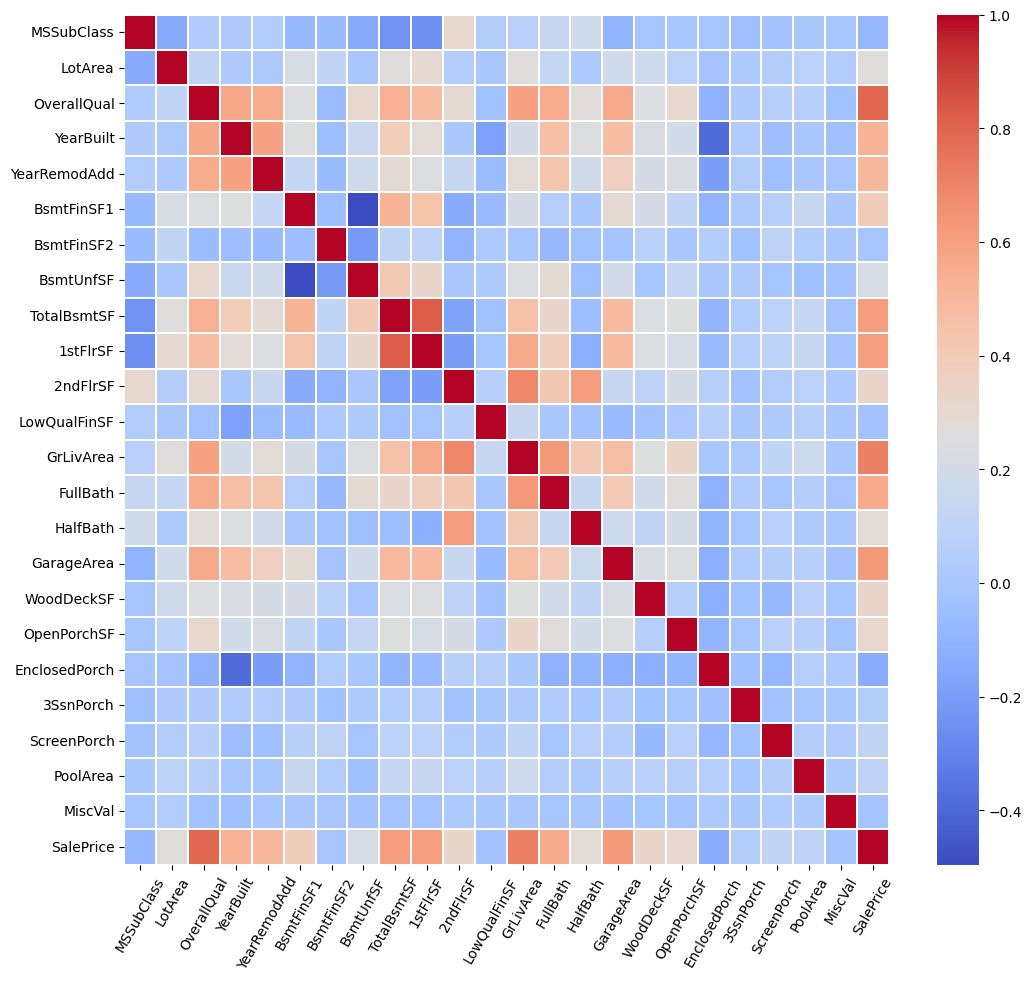

In [11]:
corr_matrix = train_df.select_dtypes(include='int64').corr()
plt.figure(figsize=(11,10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.2)
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [12]:
train_df = train_df.drop(columns=['TotalBsmtSF', 'GrLivArea'])
test_df = test_df.drop(columns=['TotalBsmtSF', 'GrLivArea'])

##### checking unique categories

In [13]:
cat_col = train_df.select_dtypes(include='object').columns
for col in cat_col:
    print(train_df[col].value_counts())
    print()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count,

In [14]:
train_df = train_df.drop(columns=['Street', 'Utilities', 'RoofMatl', 'PoolArea', 'Condition2'])
test_df = test_df.drop(columns=['Street', 'Utilities', 'RoofMatl', 'PoolArea', 'Condition2'])

In [15]:
X_train = train_df.drop(columns=['SalePrice'])
y_train = train_df['SalePrice']


## Visualization of categorial features

In [ ]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns
print(cat_cols)
print(num_cols)
for col in cat_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mode()[0])
for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train[col].median())

Index(['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle',
       'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')
Index(['MSSubClass', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'FullBath', 'HalfBath', 'GarageYrBlt',
       'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'MiscVal'],
      dtype='object')


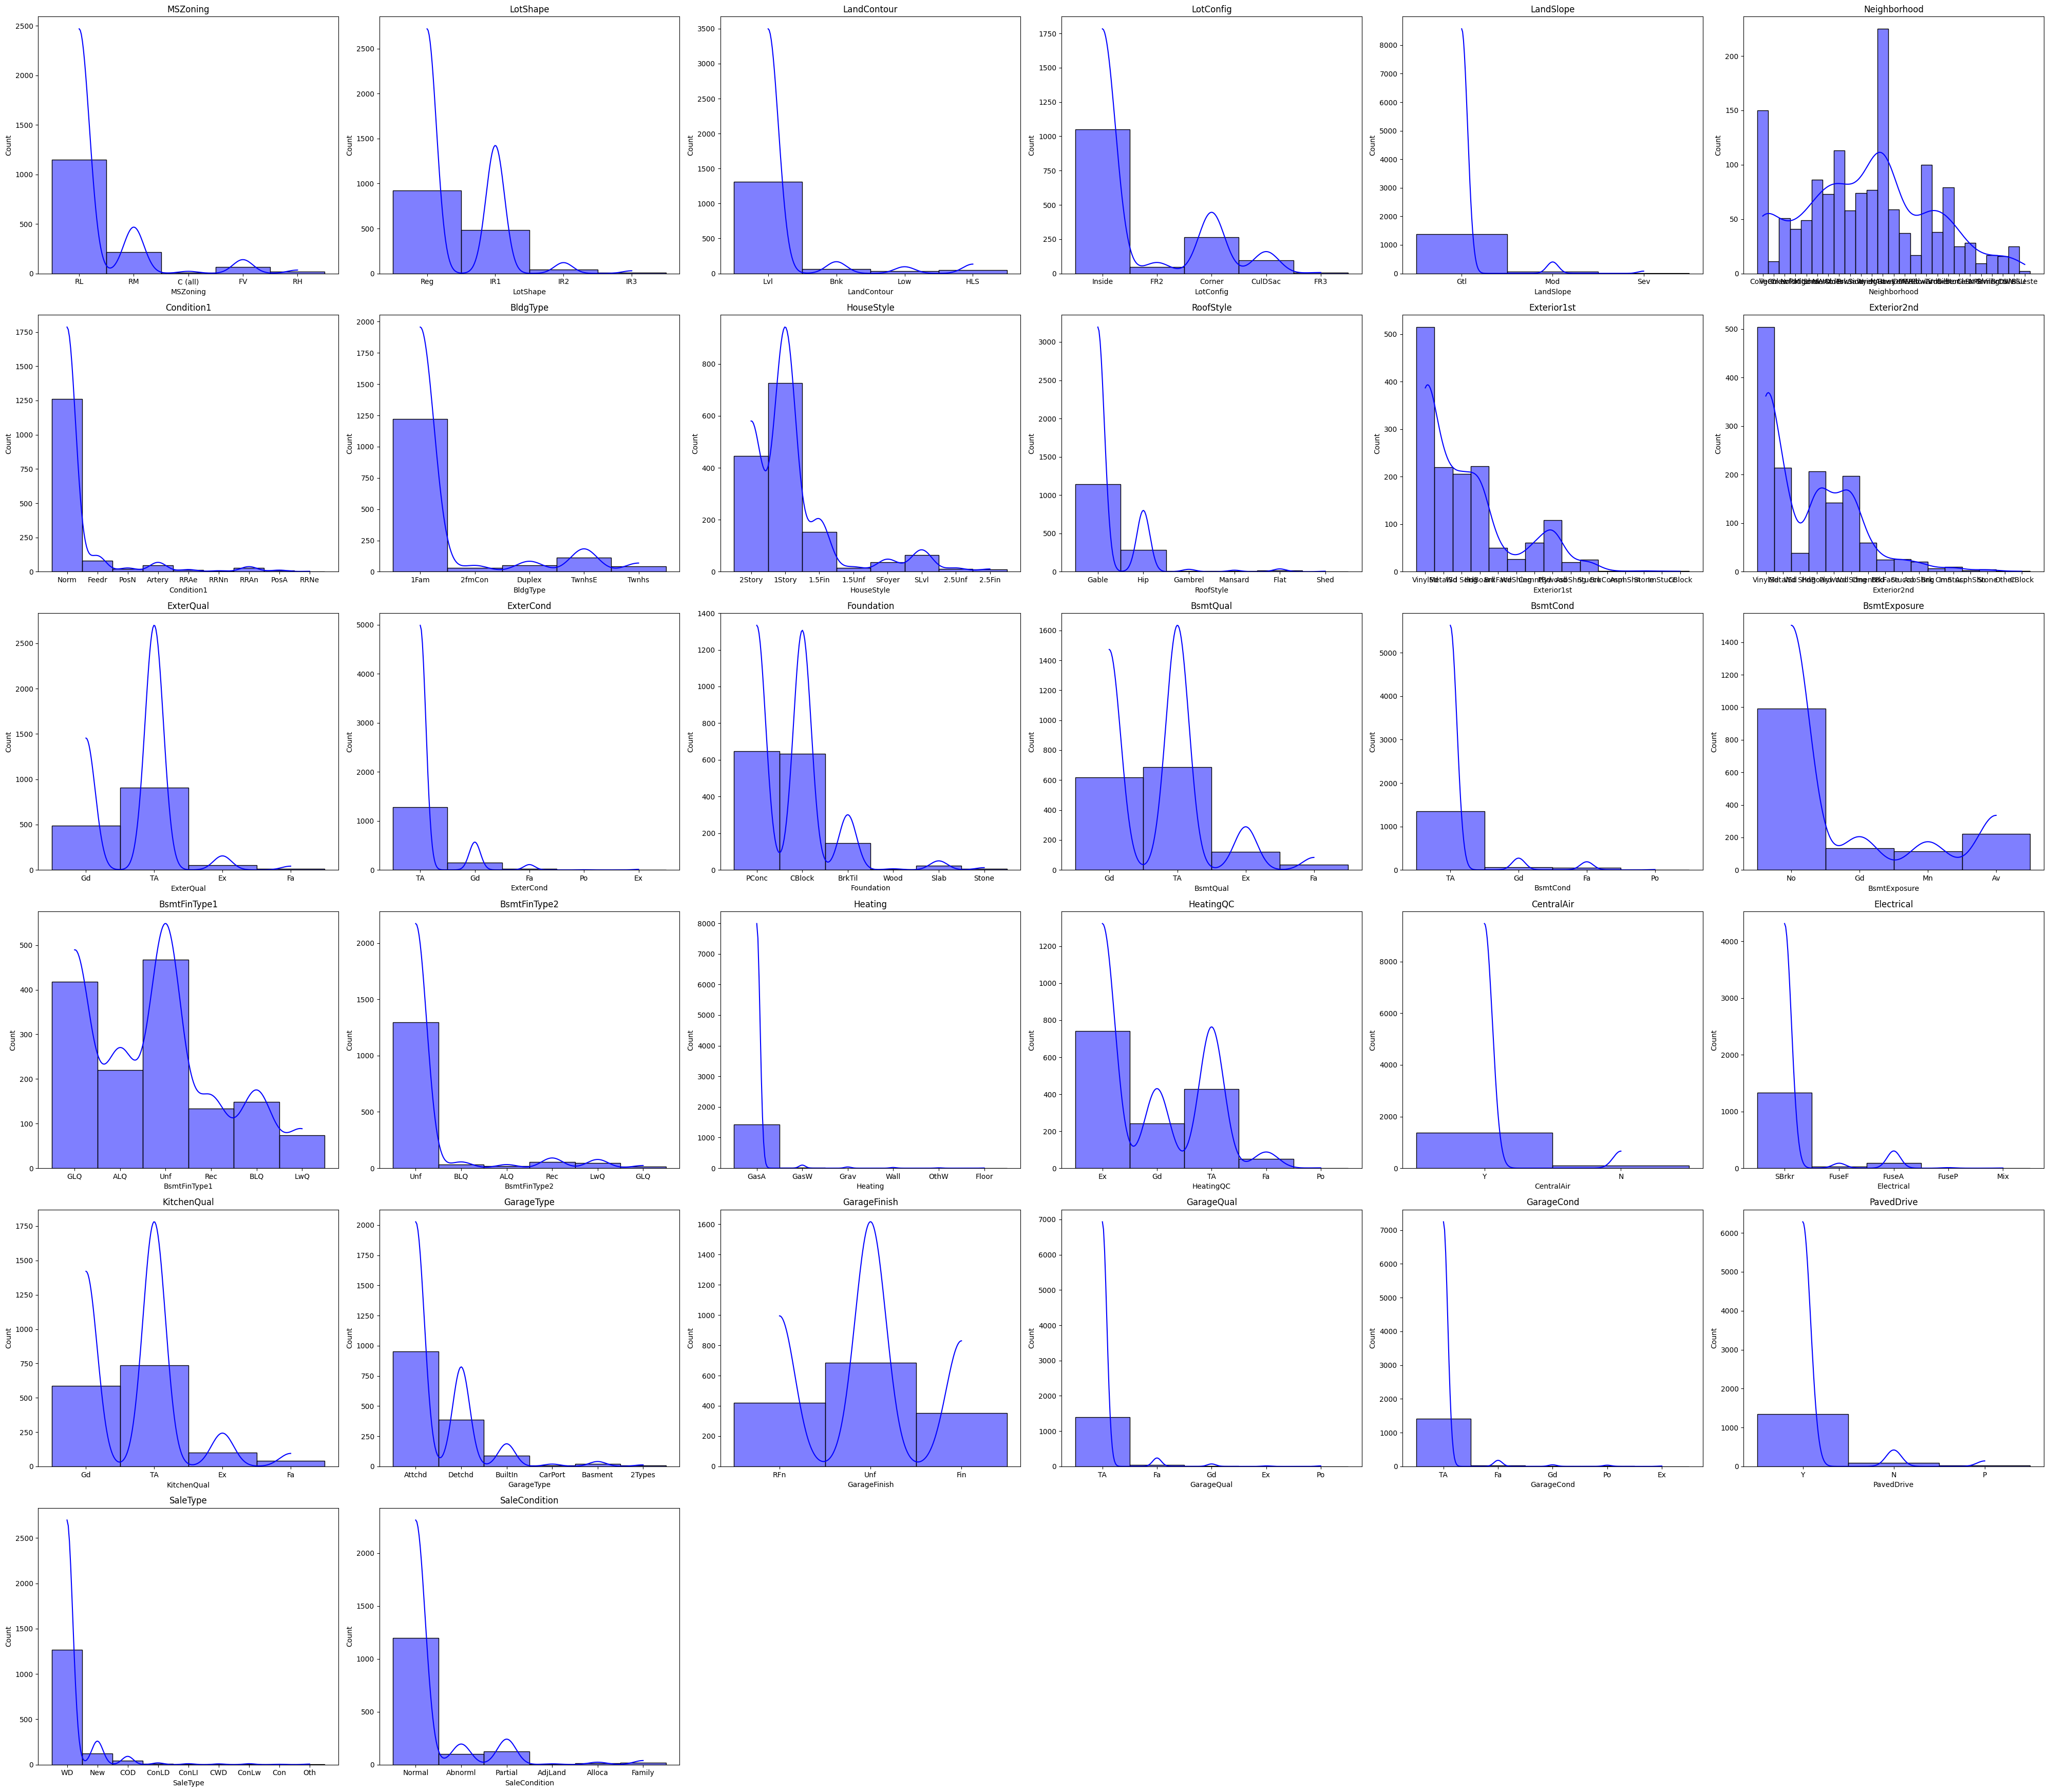

In [17]:
plt.figure(figsize=(40, 35))
row, col = 6, 6
for i, column in enumerate(X_train[cat_cols]):
    plt.subplot(row, col, i+1)
    sns.histplot(X_train[column], bins=20, kde=True, color='blue')
    plt.title(column)
    plt.tight_layout()
plt.show()

##### Dropping features that have inbalanced data

In [18]:
X_train = X_train.drop(columns=['Neighborhood', 'MSZoning', 'LandContour', 'LandSlope', 'Condition1',
                                'BldgType', 'RoofStyle', 'BsmtCond', 'ExterCond',
                                'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
                                'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
                                'SaleType', 'SaleCondition', 'LotShape', 'LotConfig', 'GarageType'])
test_df = test_df.drop(columns=['Neighborhood','MSZoning', 'LandContour', 'LandSlope', 'Condition1',
                                'BldgType', 'RoofStyle', 'BsmtCond', 'ExterCond',
                                'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
                                'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
                                'SaleType', 'SaleCondition', 'LotShape', 'LotConfig', 'GarageType'])

##### lefted cat-features

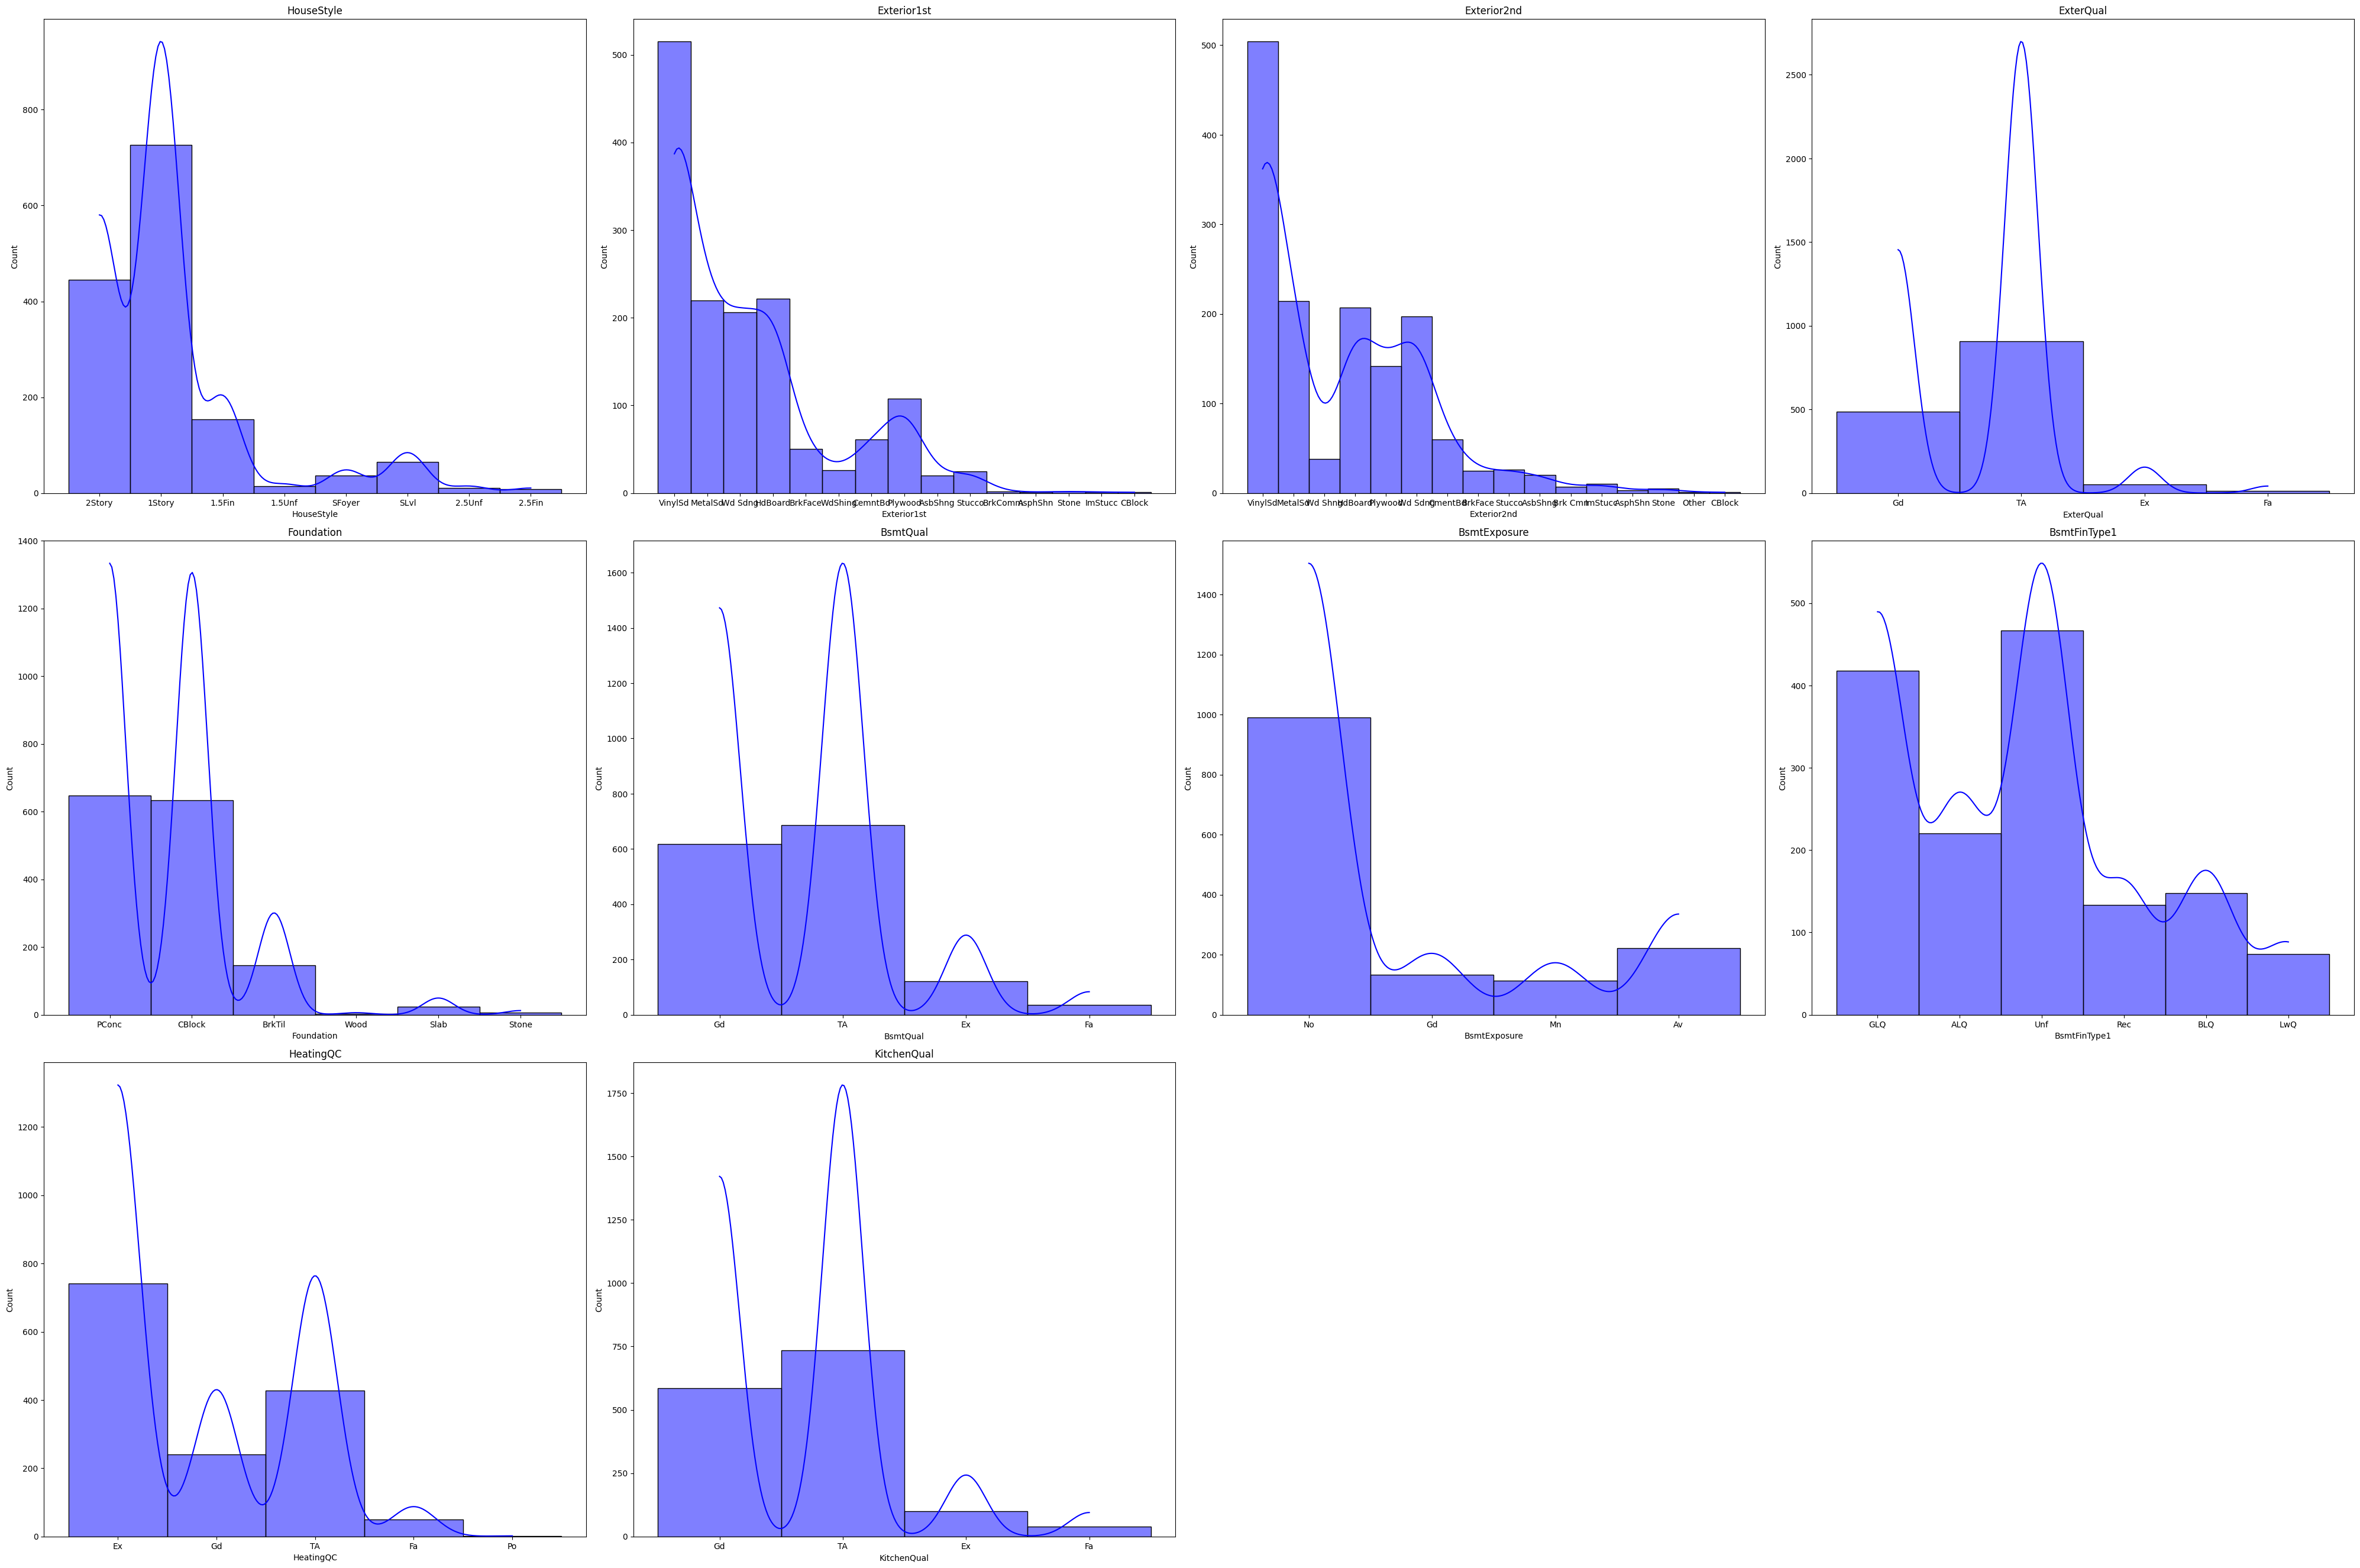

In [ ]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
plt.figure(figsize=(40, 35))
row, col = 4, 4
for i, column in enumerate(X_train[cat_cols]):
    plt.subplot(row, col, i+1)
    sns.histplot(X_train[column], bins=20, kde=True, color='blue')
    plt.title(column)
    plt.tight_layout()
plt.show()

In [20]:
cat_cols

Index(['HouseStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'Foundation',
       'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual'],
      dtype='object')

In [21]:
encoder_2 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_3 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_4 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_5 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_6 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_7 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_8 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_9 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_10 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder_11 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[['HouseStyle']] = encoder_2.fit_transform(X_train[['HouseStyle']])
X_train[['Exterior1st']] = encoder_3.fit_transform(X_train[['Exterior1st']])
X_train[['Exterior2nd']] = encoder_4.fit_transform(X_train[['Exterior2nd']])
X_train[['ExterQual']] = encoder_5.fit_transform(X_train[['ExterQual']])
X_train[['Foundation']] = encoder_6.fit_transform(X_train[['Foundation']])
X_train[['BsmtQual']] = encoder_7.fit_transform(X_train[['BsmtQual']])
X_train[['BsmtExposure']] = encoder_8.fit_transform(X_train[['BsmtExposure']])
X_train[['BsmtFinType1']] = encoder_9.fit_transform(X_train[['BsmtFinType1']])
X_train[['HeatingQC']] = encoder_10.fit_transform(X_train[['HeatingQC']])
X_train[['KitchenQual']] = encoder_11.fit_transform(X_train[['KitchenQual']])

test_df[['HouseStyle']] = encoder_2.transform(test_df[['HouseStyle']])
test_df[['Exterior1st']] = encoder_3.transform(test_df[['Exterior1st']])
test_df[['Exterior2nd']] = encoder_4.transform(test_df[['Exterior2nd']])
test_df[['ExterQual']] = encoder_5.transform(test_df[['ExterQual']])
test_df[['Foundation']] = encoder_6.transform(test_df[['Foundation']])
test_df[['BsmtQual']] = encoder_7.transform(test_df[['BsmtQual']])
test_df[['BsmtExposure']] = encoder_8.transform(test_df[['BsmtExposure']])
test_df[['BsmtFinType1']] = encoder_9.transform(test_df[['BsmtFinType1']])
test_df[['HeatingQC']] = encoder_10.transform(test_df[['HeatingQC']])
test_df[['KitchenQual']] = encoder_11.transform(test_df[['KitchenQual']])

## Choosing important features

In [22]:
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

In [23]:
print(importances.head(15).sum())
important_features = importances.head(15)

0.9641157651662452


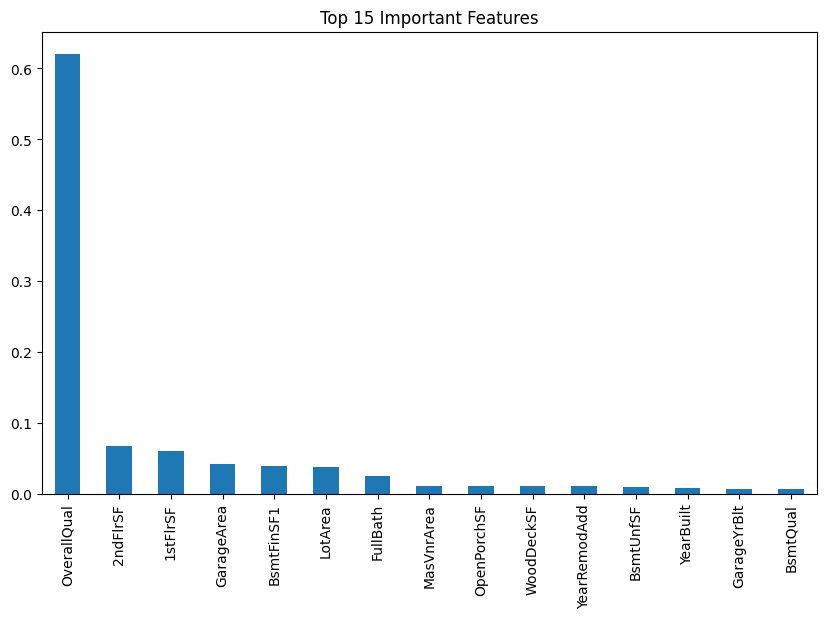

In [24]:
plt.figure(figsize=(10,6))
important_features.plot(kind='bar')
plt.title("Top 15 Important Features")
plt.show()

In [25]:
important_features = important_features.index
important_features

Index(['OverallQual', '2ndFlrSF', '1stFlrSF', 'GarageArea', 'BsmtFinSF1',
       'LotArea', 'FullBath', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF',
       'YearRemodAdd', 'BsmtUnfSF', 'YearBuilt', 'GarageYrBlt', 'BsmtQual'],
      dtype='object')

In [26]:
X_train = X_train[important_features]
test_df = test_df[important_features]
print(X_train.shape)
print(test_df.shape)


(1460, 15)
(1459, 15)


### Handling missing values

In [27]:
X_train.isna().sum()

OverallQual     0
2ndFlrSF        0
1stFlrSF        0
GarageArea      0
BsmtFinSF1      0
LotArea         0
FullBath        0
MasVnrArea      0
OpenPorchSF     0
WoodDeckSF      0
YearRemodAdd    0
BsmtUnfSF       0
YearBuilt       0
GarageYrBlt     0
BsmtQual        0
dtype: int64

In [28]:
test_df.isna().sum()

OverallQual      0
2ndFlrSF         0
1stFlrSF         0
GarageArea       1
BsmtFinSF1       1
LotArea          0
FullBath         0
MasVnrArea      15
OpenPorchSF      0
WoodDeckSF       0
YearRemodAdd     0
BsmtUnfSF        1
YearBuilt        0
GarageYrBlt     78
BsmtQual         0
dtype: int64

In [29]:
test_df['GarageArea'] = test_df['GarageArea'].fillna(test_df['GarageArea'].median())
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(test_df['MasVnrArea'].mode()[0])
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna(test_df['BsmtQual'].median())
test_df['BsmtUnfSF'] = test_df['BsmtUnfSF'].fillna(test_df['BsmtUnfSF'].median())
test_df['BsmtFinSF1'] = test_df['BsmtFinSF1'].fillna(test_df['BsmtFinSF1'].median())

In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1460 non-null   int64  
 1   2ndFlrSF      1460 non-null   int64  
 2   1stFlrSF      1460 non-null   int64  
 3   GarageArea    1460 non-null   int64  
 4   BsmtFinSF1    1460 non-null   int64  
 5   LotArea       1460 non-null   int64  
 6   FullBath      1460 non-null   int64  
 7   MasVnrArea    1460 non-null   float64
 8   OpenPorchSF   1460 non-null   int64  
 9   WoodDeckSF    1460 non-null   int64  
 10  YearRemodAdd  1460 non-null   int64  
 11  BsmtUnfSF     1460 non-null   int64  
 12  YearBuilt     1460 non-null   int64  
 13  GarageYrBlt   1460 non-null   float64
 14  BsmtQual      1460 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 171.2 KB


In [31]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1459 non-null   int64  
 1   2ndFlrSF      1459 non-null   int64  
 2   1stFlrSF      1459 non-null   int64  
 3   GarageArea    1459 non-null   float64
 4   BsmtFinSF1    1459 non-null   float64
 5   LotArea       1459 non-null   int64  
 6   FullBath      1459 non-null   int64  
 7   MasVnrArea    1459 non-null   float64
 8   OpenPorchSF   1459 non-null   int64  
 9   WoodDeckSF    1459 non-null   int64  
 10  YearRemodAdd  1459 non-null   int64  
 11  BsmtUnfSF     1459 non-null   float64
 12  YearBuilt     1459 non-null   int64  
 13  GarageYrBlt   1459 non-null   float64
 14  BsmtQual      1459 non-null   float64
dtypes: float64(6), int64(9)
memory usage: 171.1 KB


## Visualization of numeric features

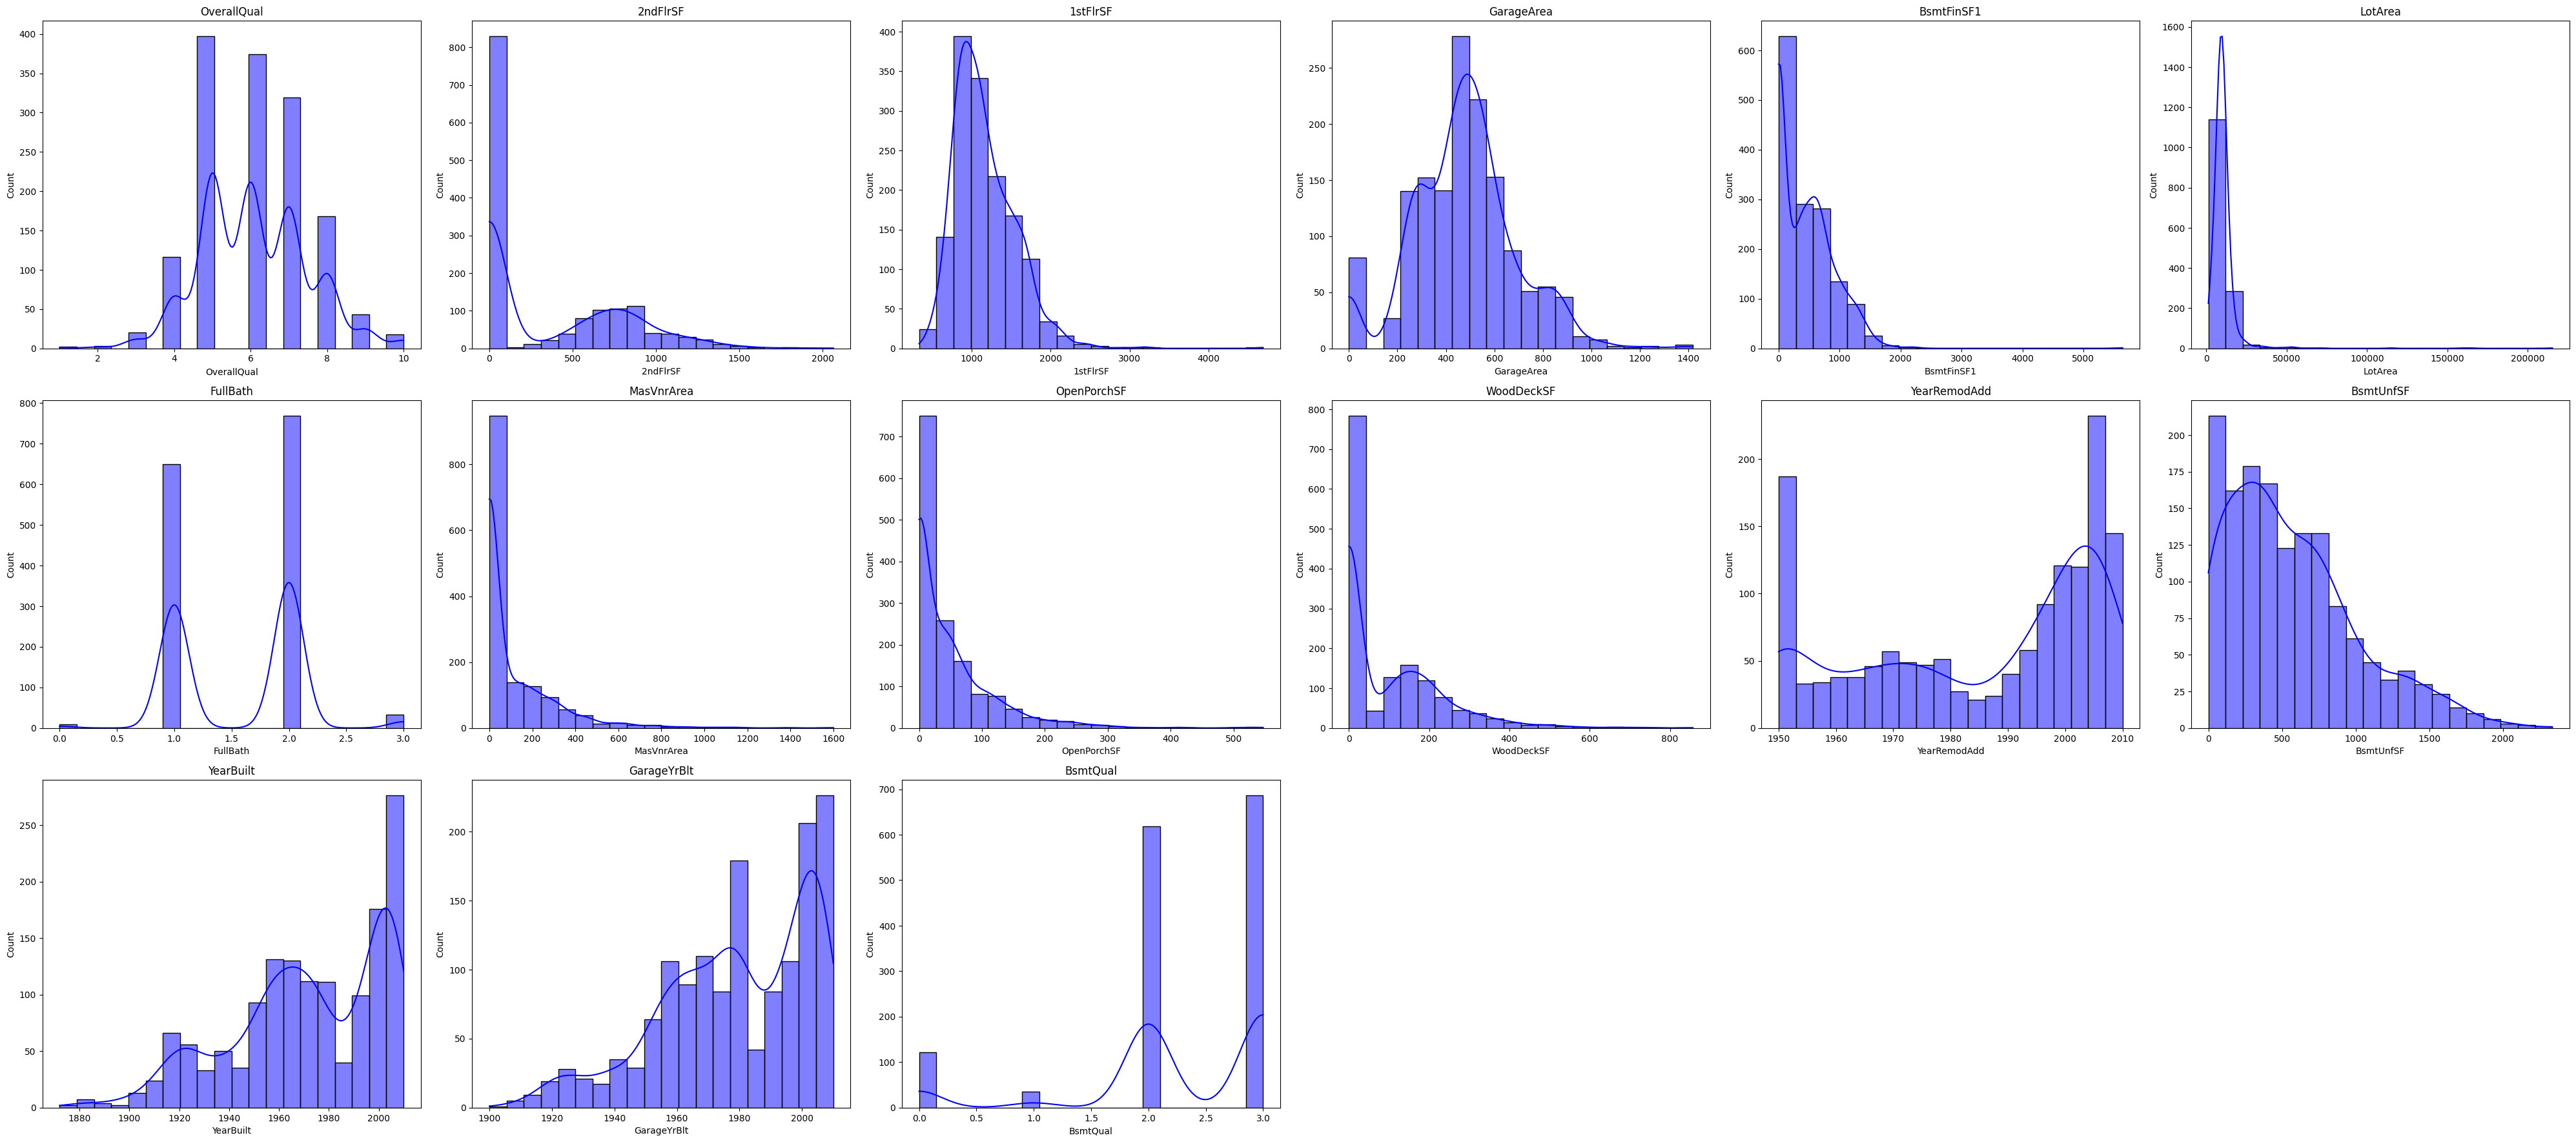

In [32]:
plt.figure(figsize=(40, 35))
row, col = 6, 6
for i, column in enumerate(X_train.columns):
    plt.subplot(row, col, i+1)
    sns.histplot(X_train[column], bins=20, kde=True, color='blue')
    plt.title(column)
    plt.tight_layout()
plt.show()

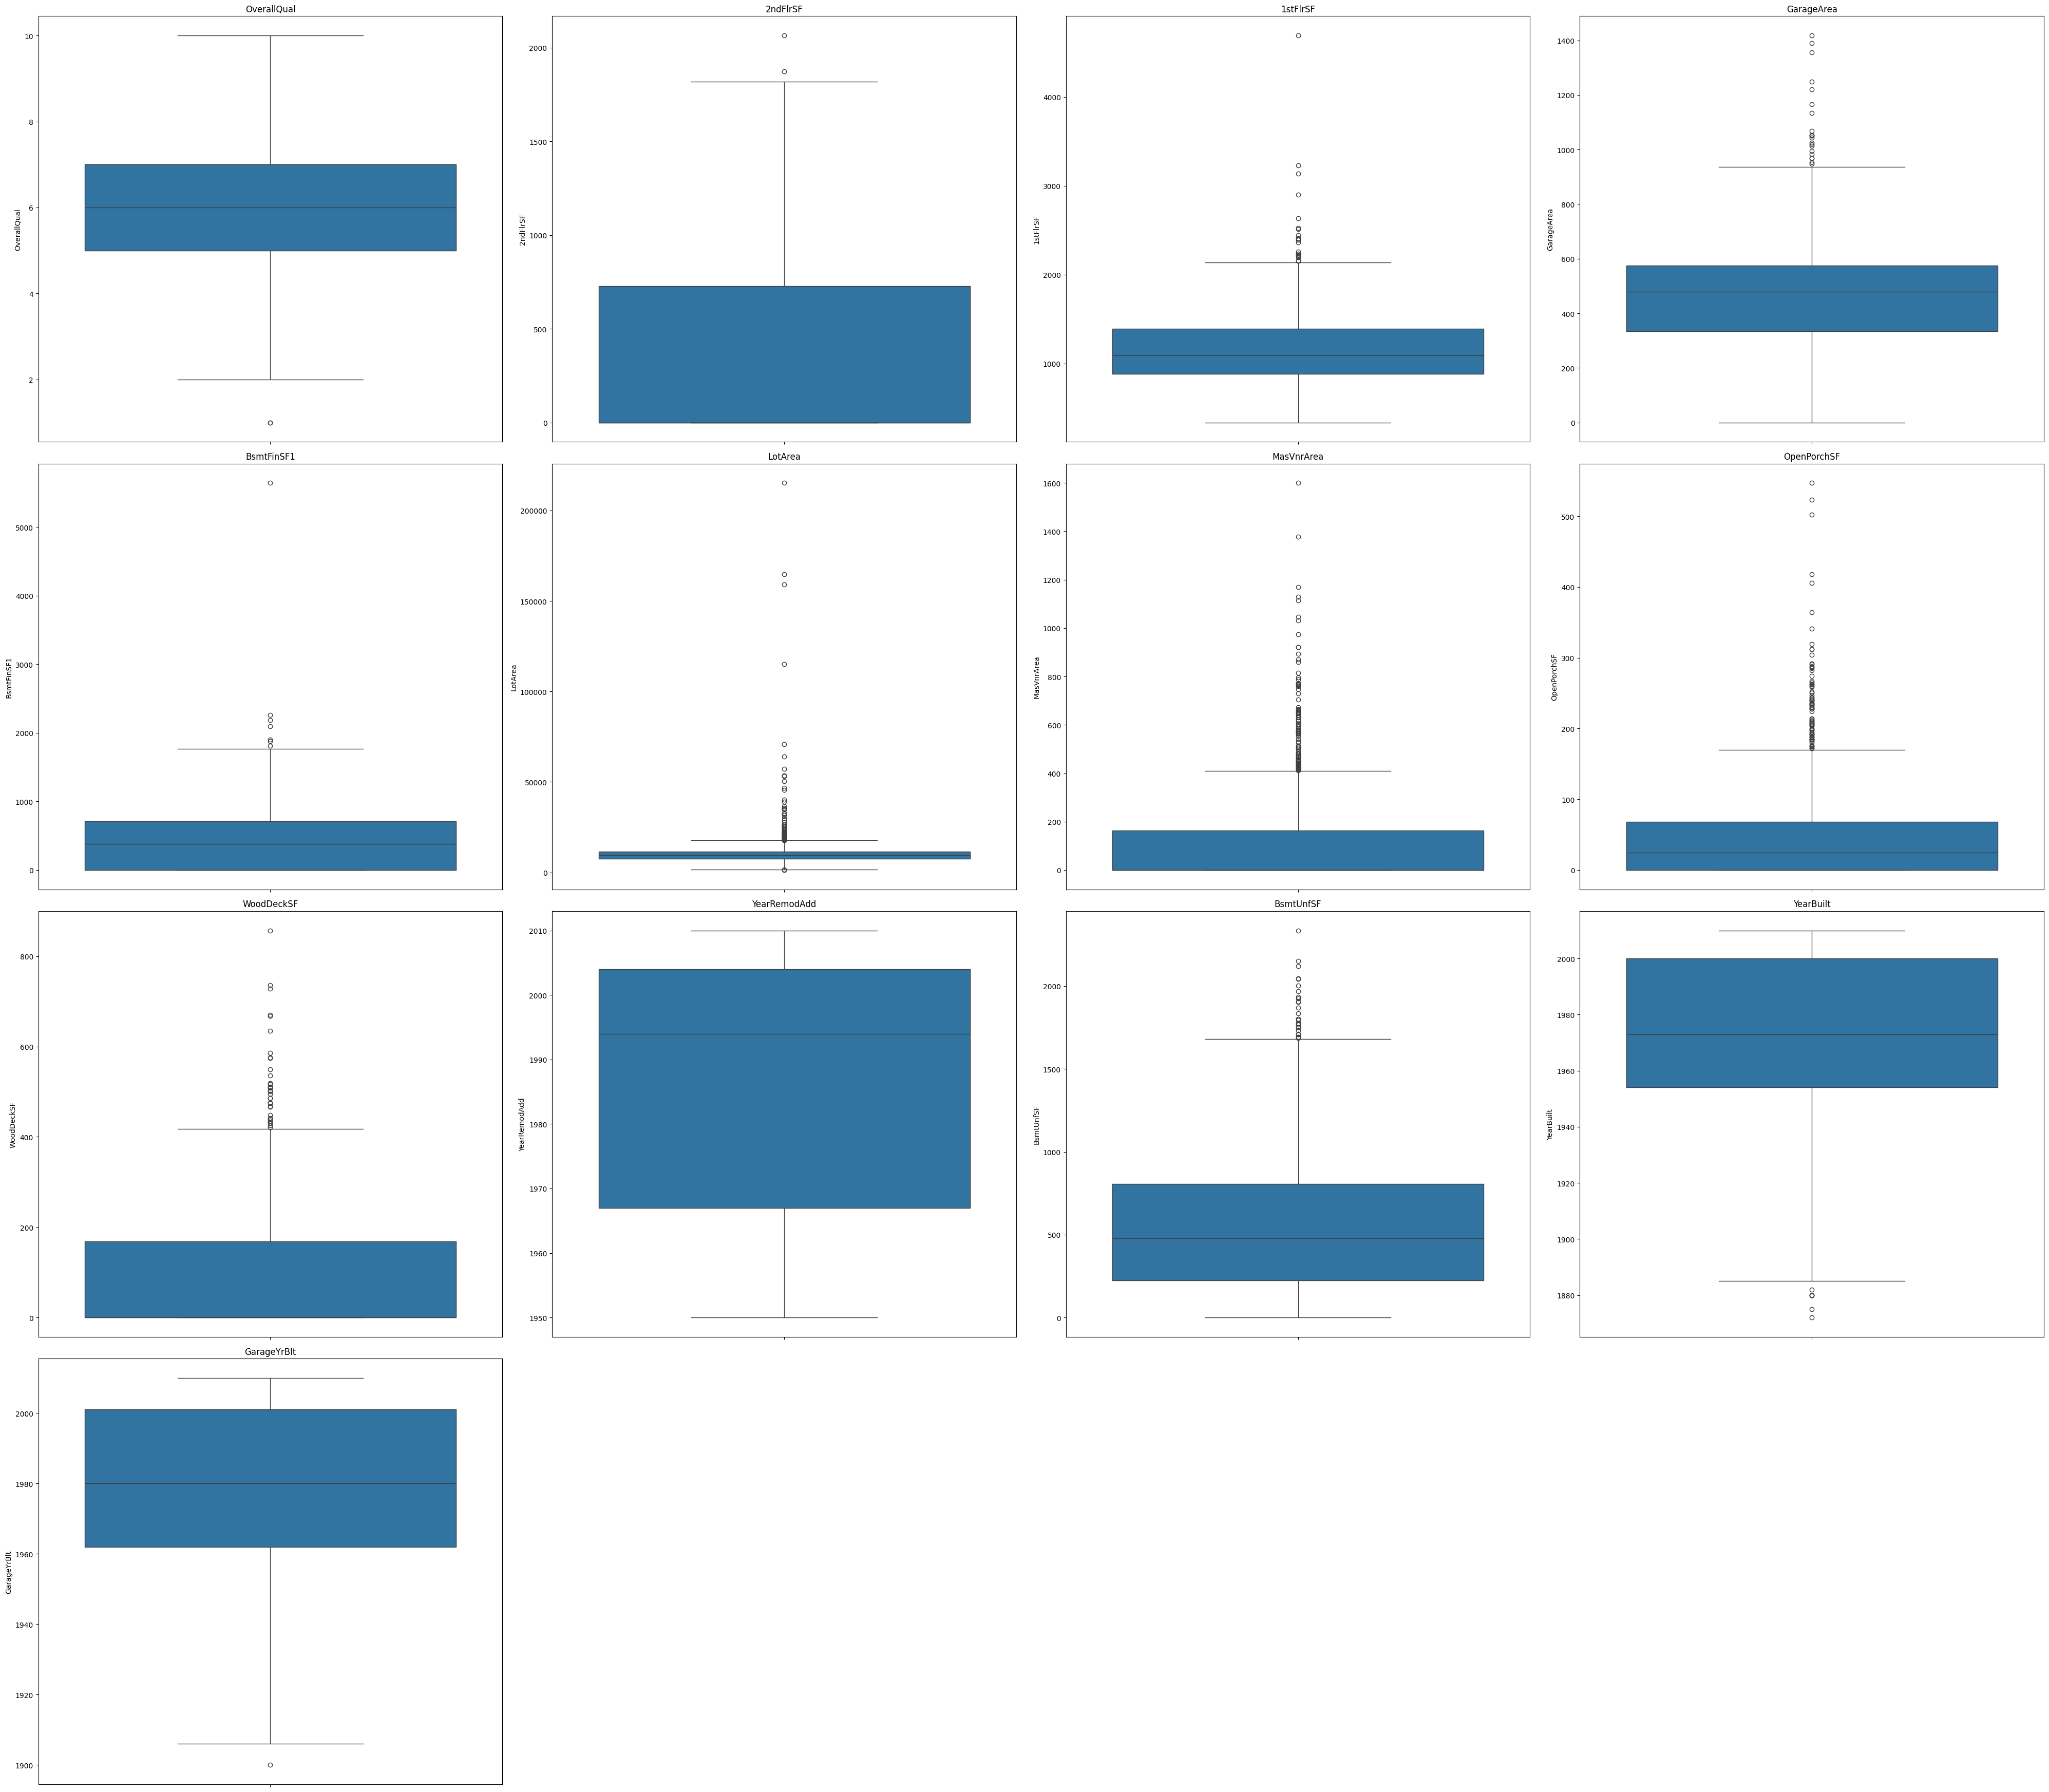

In [33]:
columns = X_train.drop(columns=['BsmtQual', 'FullBath'])
plt.figure(figsize=(40, 35))
row, col = 4, 4
for i, column in enumerate(columns):
    plt.subplot(row, col, i+1)
    sns.boxplot(X_train[column])
    plt.title(column)
    plt.tight_layout()
plt.show()

In [34]:
columns.columns

Index(['OverallQual', '2ndFlrSF', '1stFlrSF', 'GarageArea', 'BsmtFinSF1',
       'LotArea', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', 'YearRemodAdd',
       'BsmtUnfSF', 'YearBuilt', 'GarageYrBlt'],
      dtype='object')

In [35]:
# Q1 = X_train['MSSubClass'].quantile(0.25)
# Q3 = X_train['MSSubClass'].quantile(0.75)
# IQR = Q3 - Q1
# outliers = X_train[(X_train['MSSubClass'] < Q1 - 1.5*IQR) | (X_train['MSSubClass'] > Q3 + 1.5*IQR)]
# len(outliers)

In [36]:
# Q1 = X_train['GarageArea'].quantile(0.25)
# Q3 = X_train['GarageArea'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['GarageArea'] = X_train['GarageArea'].clip(lower, upper)

# Q1 = X_train['1stFlrSF'].quantile(0.25)
# Q3 = X_train['1stFlrSF'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['1stFlrSF'] = X_train['1stFlrSF'].clip(lower, upper)

# Q1 = X_train['YearBuilt'].quantile(0.25)
# Q3 = X_train['YearBuilt'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['YearBuilt'] = X_train['YearBuilt'].clip(lower, upper)

# Q1 = X_train['BsmtFinSF1'].quantile(0.25)
# Q3 = X_train['BsmtFinSF1'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['BsmtFinSF1'] = X_train['BsmtFinSF1'].clip(lower, upper)

# Q1 = X_train['2ndFlrSF'].quantile(0.25)
# Q3 = X_train['2ndFlrSF'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['2ndFlrSF'] = X_train['2ndFlrSF'].clip(lower, upper)

# Q1 = X_train['2ndFlrSF'].quantile(0.25)
# Q3 = X_train['2ndFlrSF'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['2ndFlrSF'] = X_train['2ndFlrSF'].clip(lower, upper)

# X_train['LotArea'] = np.log1p(X_train['LotArea'])

# Q1 = X_train['LotArea'].quantile(0.25)
# Q3 = X_train['LotArea'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['LotArea'] = X_train['LotArea'].clip(lower, upper)

# X_train['MasVnrArea'] = np.log1p(X_train['MasVnrArea'])

# Q1 = X_train['MasVnrArea'].quantile(0.25)
# Q3 = X_train['MasVnrArea'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['MasVnrArea'] = X_train['MasVnrArea'].clip(lower, upper)

# Q1 = X_train['OpenPorchSF'].quantile(0.25)
# Q3 = X_train['OpenPorchSF'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['OpenPorchSF'] = X_train['OpenPorchSF'].clip(lower, upper)


# Q1 = X_train['BsmtUnfSF'].quantile(0.25)
# Q3 = X_train['BsmtUnfSF'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['BsmtUnfSF'] = X_train['BsmtUnfSF'].clip(lower, upper)

# X_train['WoodDeckSF'] = np.log1p(X_train['WoodDeckSF'])

# Q1 = X_train['WoodDeckSF'].quantile(0.25)
# Q3 = X_train['WoodDeckSF'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['WoodDeckSF'] = X_train['WoodDeckSF'].clip(lower, upper)


# Q1 = X_train['MSSubClass'].quantile(0.25)
# Q3 = X_train['MSSubClass'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR
# X_train['MSSubClass'] = X_train['MSSubClass'].clip(lower, upper)

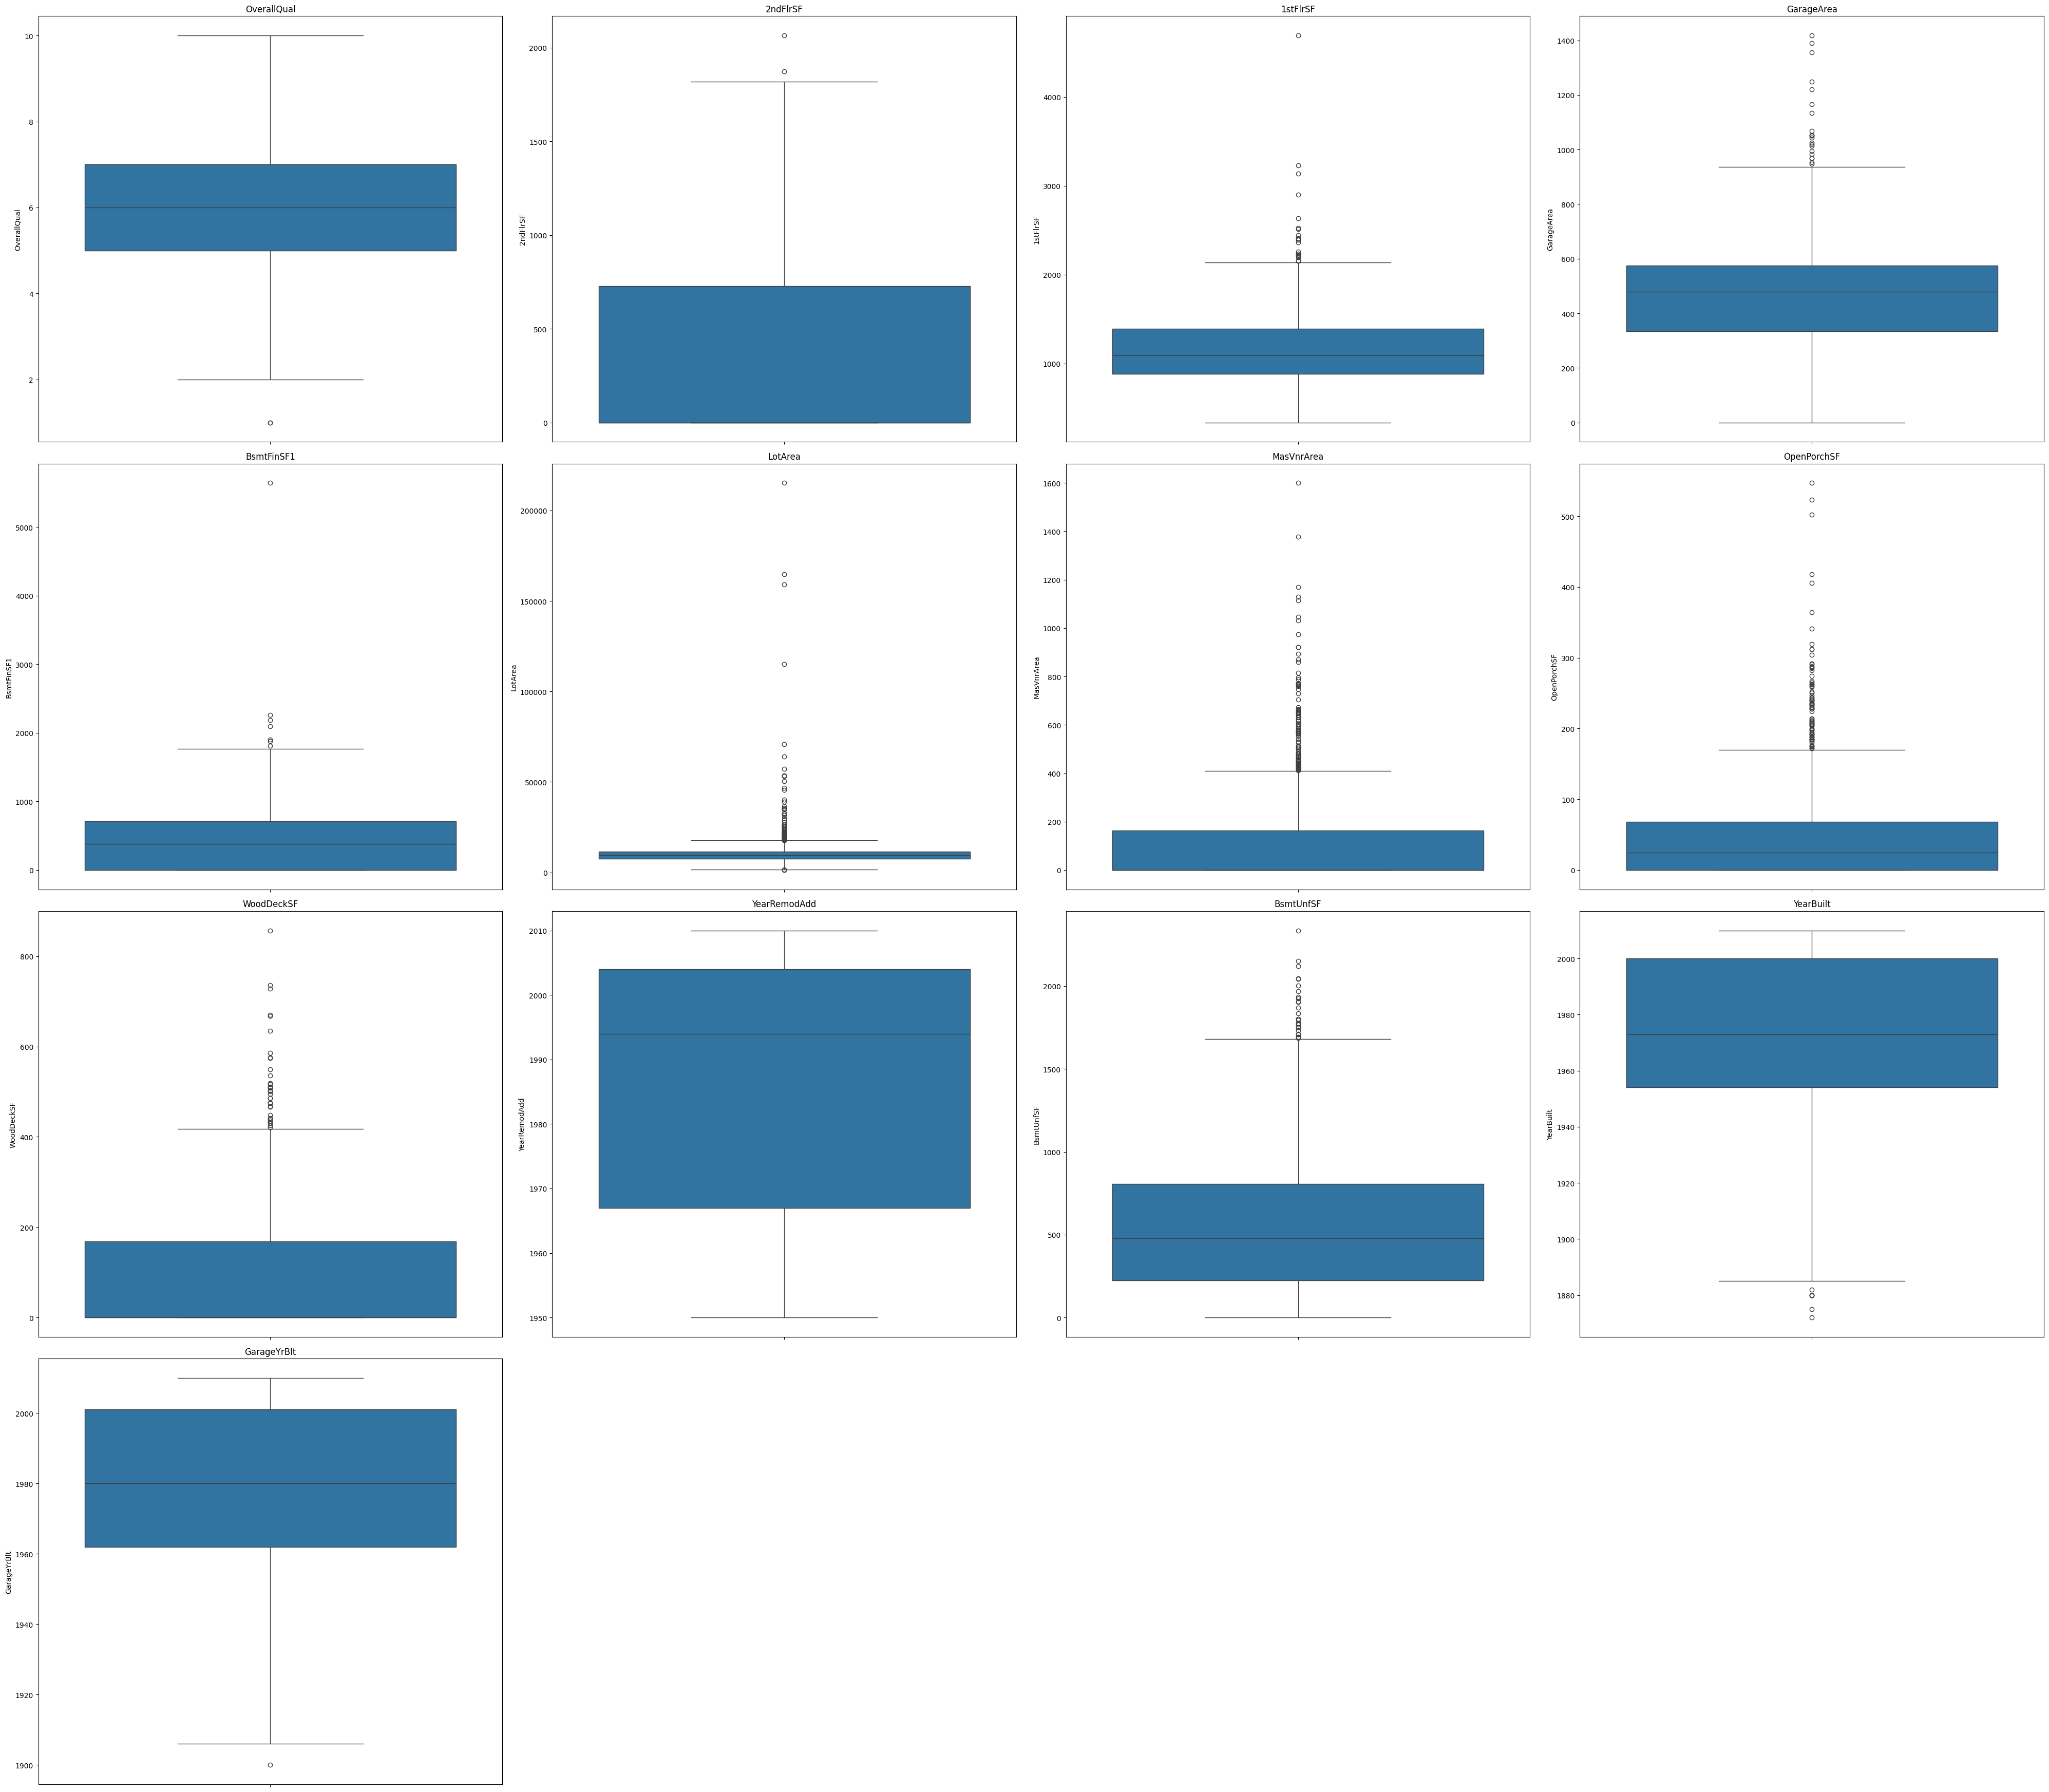

In [37]:
columns = X_train.drop(columns=['BsmtQual', 'FullBath'])
plt.figure(figsize=(40, 35))
row, col = 4, 4
for i, column in enumerate(columns):
    plt.subplot(row, col, i+1)
    sns.boxplot(X_train[column])
    plt.title(column)
    plt.tight_layout()
plt.show()

In [38]:

X_train = X_train.drop(columns=['BsmtQual', 'FullBath'])
test_df = test_df.drop(columns=['BsmtQual', 'FullBath'])

## Saving to CSV

In [39]:
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
test_df.to_csv("test.csv", index=False)
Id_test.to_csv("ID's.csv", index=False)